## **TESTING SCRIPTS**

### **Test parameters**
Number of floorplans ``N = 10``

___

#### **``run_subset.py``**

**Total runtime: 89.647 seconds**

In [7]:
total_time = 4571/10 * 89.647

print(f"Expected time to run on all data: ", total_time/60, "mins\n", 
"                                 ", total_time/3600, "hours")

print(0.382678805555559*60)


Expected time to run on all data:  682.9607283333335 mins
                                   11.382678805555559 hours
22.96072833333354


Profiling shows that the main bottleneck is the Jacobi update expression. 89.5128s of 89.647s are spent on the ``jacobi()`` function.

In particular, line 38 accounts for about 50.3% of the measured time, where the left-neighbor slice participates in the vectorized sum. However, this does not mean that only the left-neighbor access is inherently expensive by itself; rather, line profiling attributes much of the cost of the full multi-array expression to that line.

Significant time is also spent on lines 44–45, where masked indexing extracts the current and newly computed values at interior points, on line 47 where the maximum update difference is computed, and on line 48 where masked assignment writes values back into the grid.

The underlying issue is not that every array access duplicates the whole array. Ordinary slicing such as u[1:-1, :-2] usually creates a view, not a full copy. The expensive part is that the vectorized arithmetic and masked indexing create temporary arrays and involve substantial memory traffic. In particular, boolean indexing like ``u[1:-1, 1:-1][interior_mask]`` produces a copy of the selected elements, which is more memory-intensive and less cache-friendly.

___

### **``run_subset_5.py``**

#### **``--workers 1``**

In [14]:
total_time = 4571/10 * 93.801

print(f"Expected time to run on all data: ", total_time/60, "mins\n", 
"                                 ", total_time/3600, "hours")

Expected time to run on all data:  714.607285 mins
                                   11.910121416666668 hours


___

#### **``--workers 2``**

In [15]:
total_time = 4571/10 * 65.623

print(f"Expected time to run on all data: ", total_time/60, "mins\n", 
"                                 ", total_time/3600, "hours")

Expected time to run on all data:  499.93788833333343 mins
                                   8.33229813888889 hours


___

#### **``--workers 4``**

In [16]:
total_time = 4571/10 * 62.960

print(f"Expected time to run on all data: ", total_time/60, "mins\n", 
"                                 ", total_time/3600, "hours")

Expected time to run on all data:  479.6502666666667 mins
                                   7.994171111111112 hours


___

#### **``--workers 8``**

In [17]:
total_time = 4571/10 * 52.249

print(f"Expected time to run on all data: ", total_time/60, "mins\n", 
"                                 ", total_time/3600, "hours")

Expected time to run on all data:  398.0502983333334 mins
                                   6.63417163888889 hours


___

For small problem sizes such as 10 floorplans, increasing the worker count beyond 4 gives limited benefit, because each worker receives only one or two floorplans under static scheduling. In that regime, process-management overhead and load imbalance reduce the achievable speedup. Therefore, larger subsets such as 50 or 100 floorplans are more appropriate for measuring parallel scaling:

In [14]:
total_time_1 = 4571/100 * 617.549
total_time_2 = 4571/100 * 325.178
total_time_3 = 4571/100 * 168.812
total_time_4 = 4571/100 * 119.130
total_time_5 = 4571/100 * 96.655
total_time_6 = 4571/100 * 88.283
total_time_7 = 4571/100 * 95.239

print(f"Expected time to run on all data (1 worker): ", total_time_1/60, "mins\n", 
"                                            ", total_time_1/3600, "hours")
print(f"Expected time to run on all data (2 workers): ", total_time_2/60, "mins\n", 
"                                             ", total_time_2/3600, "hours")
print(f"Expected time to run on all data (4 workers): ", total_time_3/60, "mins\n", 
"                                             ", total_time_3/3600, "hours")
print(f"Expected time to run on all data (8 workers): ", total_time_4/60, "mins\n", 
"                                             ", total_time_4/3600, "hours")
print(f"Expected time to run on all data (16 workers): ", total_time_5/60, "mins\n", 
"                                              ", total_time_5/3600, "hours")
print(f"Expected time to run on all data (32 workers): ", total_time_6/60, "mins\n", 
"                                              ", total_time_6/3600, "hours")
print(f"Expected time to run on all data (64 workers): ", total_time_7/60, "mins\n", 
"                                              ", total_time_7/3600, "hours")

Expected time to run on all data (1 worker):  470.46941316666664 mins
                                              7.8411568861111105 hours
Expected time to run on all data (2 workers):  247.73143966666666 mins
                                               4.128857327777777 hours
Expected time to run on all data (4 workers):  128.60660866666666 mins
                                               2.1434434777777778 hours
Expected time to run on all data (8 workers):  90.75720499999998 mins
                                               1.5126200833333332 hours
Expected time to run on all data (16 workers):  73.63500083333334 mins
                                                1.2272500138888889 hours
Expected time to run on all data (32 workers):  67.25693216666667 mins
                                                1.1209488694444445 hours
Expected time to run on all data (64 workers):  72.55624483333334 mins
                                                1.2092707472222224 hours


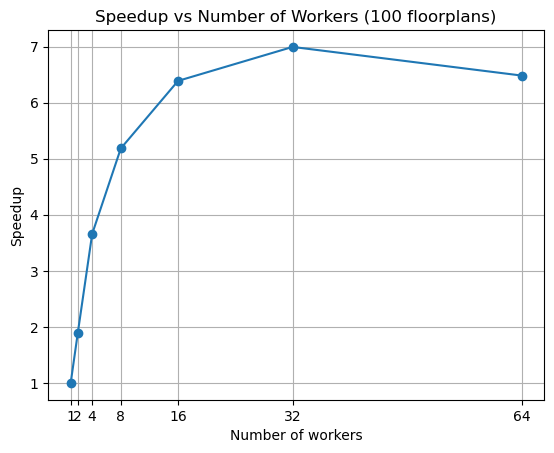

In [9]:
# Create speedup plot from provided data
import matplotlib.pyplot as plt

workers = [1, 2, 4, 8, 16, 32, 64]
times = [617.549, 325.178, 168.812, 119.130, 96.655, 88.283, 95.239]

# Compute speedup relative to 1 worker
baseline = times[0]
speedup = [baseline / t for t in times]

plt.figure()
plt.plot(workers, speedup, marker='o')
plt.xlabel("Number of workers")
plt.ylabel("Speedup")
plt.title("Speedup vs Number of Workers (100 floorplans)")
plt.xticks(workers)
plt.grid()
plt.show()

In [10]:
617.549/88.283

6.995106645673572

In [11]:
(1 - 1/6.995106645673572)/(1 - 1/32)

0.8846894688100759

In [12]:
1/(1-0.8846894688100759)

8.672234787930462

#### **Amdahl's Law**

Amdahl's law says $$S_p = \frac{1}{(1-f) + \frac{f}{p}}$$ where $S_p$ is the measured speedup with $p$ workers, and $f$ is the parallel fraction.

The best **measured speedup** with 32 workers is $$S_{32} = \frac{T_1}{T_{32}} = \frac{617.549}{88.283} \approx 6.995$$ We can then estimate the parallel fraction $f$ using Amdahl's law as follows:
$$
S_p = \frac{1}{(1 - f) + \frac{f}{p}}
\quad \Rightarrow \quad
\frac{1}{S_p} = 1 - f + \frac{f}{p}
\quad \Rightarrow \quad
\frac{1}{S_p} = 1 - f\left(1 - \frac{1}{p}\right)
$$

$$
f\left(1 - \frac{1}{p}\right) = 1 - \frac{1}{S_p}
\quad \Rightarrow \quad
f = \frac{1 - \frac{1}{S_p}}{1 - \frac{1}{p}} = \frac{1 - \frac{1}{6.995}}{1 - \frac{1}{32}} \approx 0.885
$$

So the estimated parallel fraction is about 91.7%, meaning roughly 92% of the program is parallelized and about 8.3% remains serial. The **theoretical maximum speedup** according to Amdahl's law is given by $$S_{\max} = \frac{1}{1-f} = \frac{1}{1-0.885} \approx 8.672$$

___

Using the best measured configuration of 16 workers, the observed speedup was $S_{32} \approx 7$. Applying Amdahl’s law gives an estimated parallel fraction of $f = 0.885$, meaning that roughly 89\% of the computation is parallelized. This implies a theoretical maximum speedup of about $12\times$. Our measured best speedup of $7\times$ therefore corresponds to about 59\% of the theoretical maximum. Increasing the worker count further to 64 reduced performance, indicating that overhead and resource contention outweighed the benefit of additional parallelism.

In [13]:
4571/100 * 88.283

4035.41593

Using the fastest configuration of 32 workers, the runtime for 100 floorplans was measured to be approximately 88.283 seconds. Assuming linear scaling with respect to the number of floorplans, the total runtime for all 4571 buildings is estimated as:$$T_{all} = \frac{4571}{100} \cdot T_{100} = \frac{4571}{100} \cdot 88.283\,\text{s} = 4035.41\,\text{s}$$ which corresponds to approximately 67 minutes or 1.12 hours.

___

### **``run_subset_6.py``**

In [15]:
total_time_1 = 4571/100 * 598.146
total_time_2 = 4571/100 * 292.610
total_time_3 = 4571/100 * 163.960
total_time_4 = 4571/100 * 83.621
total_time_5 = 4571/100 * 88.275
total_time_6 = 4571/100 * 93.324
total_time_7 = 4571/100 * 95.961

print(f"Expected time to run on all data (1 worker): ", total_time_1/60, "mins\n", 
"                                            ", total_time_1/3600, "hours")
print(f"Expected time to run on all data (2 workers): ", total_time_2/60, "mins\n", 
"                                             ", total_time_2/3600, "hours")
print(f"Expected time to run on all data (4 workers): ", total_time_3/60, "mins\n", 
"                                             ", total_time_3/3600, "hours")
print(f"Expected time to run on all data (8 workers): ", total_time_4/60, "mins\n", 
"                                             ", total_time_4/3600, "hours")
print(f"Expected time to run on all data (16 workers): ", total_time_5/60, "mins\n", 
"                                              ", total_time_5/3600, "hours")
print(f"Expected time to run on all data (32 workers): ", total_time_6/60, "mins\n", 
"                                              ", total_time_6/3600, "hours")
print(f"Expected time to run on all data (64 workers): ", total_time_7/60, "mins\n", 
"                                              ", total_time_7/3600, "hours")

Expected time to run on all data (1 worker):  455.68756099999996 mins
                                              7.594792683333333 hours
Expected time to run on all data (2 workers):  222.92005166666667 mins
                                               3.7153341944444445 hours
Expected time to run on all data (4 workers):  124.91019333333334 mins
                                               2.081836555555556 hours
Expected time to run on all data (8 workers):  63.70526516666666 mins
                                               1.0617544194444444 hours
Expected time to run on all data (16 workers):  67.2508375 mins
                                                1.1208472916666667 hours
Expected time to run on all data (32 workers):  71.097334 mins
                                                1.1849555666666667 hours
Expected time to run on all data (64 workers):  73.10628849999999 mins
                                                1.2184381416666665 hours


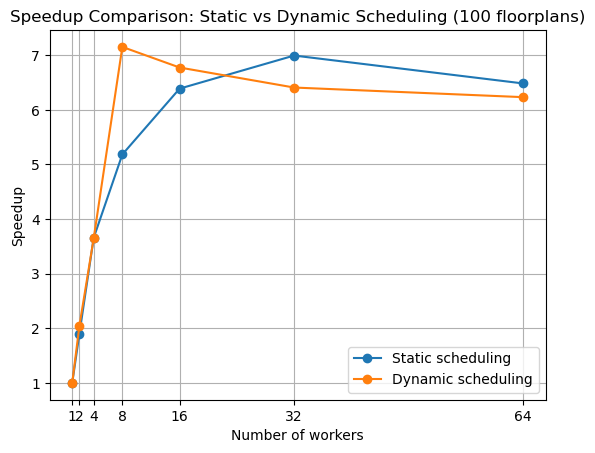

In [16]:
# Plot comparison between static (Task 5) and dynamic (Task 6)
import matplotlib.pyplot as plt

# Workers
workers = [1, 2, 4, 8, 16, 32, 64]

# Static (Task 5) times
times_static = [617.549, 325.178, 168.812, 119.130, 96.655, 88.283, 95.239]

# Dynamic (Task 6) times
times_dynamic = [598.146, 292.610, 163.960, 83.621, 88.275, 93.324, 95.961]

# Compute speedups
baseline_static = times_static[0]
baseline_dynamic = times_dynamic[0]

speedup_static = [baseline_static / t for t in times_static]
speedup_dynamic = [baseline_dynamic / t for t in times_dynamic]

# Plot
plt.figure()
plt.plot(workers, speedup_static, marker='o', label='Static scheduling')
plt.plot(workers, speedup_dynamic, marker='o', label='Dynamic scheduling')

plt.xlabel("Number of workers")
plt.ylabel("Speedup")
plt.title("Speedup Comparison: Static vs Dynamic Scheduling (100 floorplans)")
plt.xticks(workers)
plt.legend()
plt.grid()
plt.show()

Dynamic scheduling significantly improves performance compared to static scheduling for small to moderate numbers of workers. Floorplans require different numbers of Jacobi iterations to converge, leading to load imbalance in the static case where workers are assigned fixed subsets. With dynamic scheduling, workers receive new floorplans as soon as they finish their current task, reducing idle time and improving resource utilization. For larger numbers of workers, the performance difference between the two approaches diminishes, as overhead and hardware limitations such as memory bandwidth become the dominant factors.

The results clearly demonstrate that dynamic scheduling mitigates load imbalance, particularly at lower worker counts, resulting in significantly higher speedups compared to static scheduling.

___

#### **``run_subset_7.py``**


In [24]:
total_time1 = 4571/100 * 32.039
total_time2 = 4571/100 * 20.848
total_time3 = 4571/100 * 20.326
total_time4 = 4571/100 * 19.980
total_time5 = 4571/100 * 19.400
total_time6 = 4571/100 * 20.372

print(f"Expected time to run on all data (8 workers, static): ", total_time_1/60, "mins\n", 
"                                                      ", total_time_1/3600, "hours")
print(f"Expected time to run on all data (8 workers, dynamic): ", total_time_2/60, "mins\n", 
"                                                      ", total_time_2/3600, "hours")
print(f"Expected time to run on all data (16 workers, static): ", total_time_3/60, "mins\n", 
"                                                      ", total_time_3/3600, "hours")
print(f"Expected time to run on all data (16 workers, dynamic): ", total_time_4/60, "mins\n", 
"                                                      ", total_time_4/3600, "hours")
print(f"Expected time to run on all data (32 workers, static): ", total_time_5/60, "mins\n", 
"                                                      ", total_time_5/3600, "hours")
print(f"Expected time to run on all data (32 workers, dynamic): ", total_time_6/60, "mins\n", 
"                                                       ", total_time_6/3600, "hours")

Expected time to run on all data (8 workers, static):  455.68756099999996 mins
                                                        7.594792683333333 hours
Expected time to run on all data (8 workers, dynamic):  222.92005166666667 mins
                                                        3.7153341944444445 hours
Expected time to run on all data (16 workers, static):  124.91019333333334 mins
                                                        2.081836555555556 hours
Expected time to run on all data (16 workers, dynamic):  63.70526516666666 mins
                                                        1.0617544194444444 hours
Expected time to run on all data (32 workers, static):  67.2508375 mins
                                                        1.1208472916666667 hours
Expected time to run on all data (32 workers, dynamic):  71.097334 mins
                                                         1.1849555666666667 hours
